# Load schema

In [2]:
%matplotlib inline

In [3]:
import pyarrow.parquet as pq

cam_images_parquet_path = "/workspaces/object_detection/data/waymo/raw/training/camera_image/10017090168044687777_6380_000_6400_000.parquet"
schema = pq.read_schema(cam_images_parquet_path)
print(len(schema))
print(schema)

16
index: string
key.segment_context_name: string
key.frame_timestamp_micros: int64
key.camera_name: int8
[CameraImageComponent].image: binary
[CameraImageComponent].pose.transform: fixed_size_list<item: double>[16]
  child 0, item: double
[CameraImageComponent].velocity.linear_velocity.x: float
[CameraImageComponent].velocity.linear_velocity.y: float
[CameraImageComponent].velocity.linear_velocity.z: float
[CameraImageComponent].velocity.angular_velocity.x: double
[CameraImageComponent].velocity.angular_velocity.y: double
[CameraImageComponent].velocity.angular_velocity.z: double
[CameraImageComponent].pose_timestamp: double
[CameraImageComponent].rolling_shutter_params.shutter: double
[CameraImageComponent].rolling_shutter_params.camera_trigger_time: double
[CameraImageComponent].rolling_shutter_params.camera_readout_done_time: double
-- schema metadata --
pandas: '{"column_indexes": [{"field_name": null, "metadata": {"encoding"' + 3109


# Load necessary columns from table

In [4]:
import pandas as pd
cam_df = pq.read_table(cam_images_parquet_path, columns=["key.segment_context_name", "key.frame_timestamp_micros", "key.camera_name",  "[CameraImageComponent].image"]).to_pandas()

# Load calibration


In [5]:
import numpy as np
cam_calibration_parquet_path = "/workspaces/object_detection/data/waymo/raw/training/camera_calibration/10017090168044687777_6380_000_6400_000.parquet"
calib_df = pq.read_table(cam_calibration_parquet_path).to_pandas()
print(calib_df.columns)
# merge camera imaages and calibration data
merged_df = pd.merge(cam_df, calib_df, on= ["key.segment_context_name","key.camera_name"])

# Decode calibration
row = calib_df[calib_df['key.camera_name'] == 1]
# Intrinsics: [f_u, f_v, c_u, c_v, k1, k2, p1, p2, k3]
intrinsics = np.array([row['[CameraCalibrationComponent].intrinsic.f_u'], row['[CameraCalibrationComponent].intrinsic.f_v'], row['[CameraCalibrationComponent].intrinsic.c_u'], row['[CameraCalibrationComponent].intrinsic.c_v'], row['[CameraCalibrationComponent].intrinsic.k1'], row['[CameraCalibrationComponent].intrinsic.k2'], row['[CameraCalibrationComponent].intrinsic.p1'], row['[CameraCalibrationComponent].intrinsic.p2'], row['[CameraCalibrationComponent].intrinsic.k3']])

# Extrinsics: 4x4 pose matrix (camera from vehicle)
extrinsic = np.asarray(row['[CameraCalibrationComponent].extrinsic.transform'][0]).reshape(4, 4)
print("Intrinsics:", intrinsics)
print("Extrinsic:\n", extrinsic)

Index(['key.segment_context_name', 'key.camera_name',
       '[CameraCalibrationComponent].intrinsic.f_u',
       '[CameraCalibrationComponent].intrinsic.f_v',
       '[CameraCalibrationComponent].intrinsic.c_u',
       '[CameraCalibrationComponent].intrinsic.c_v',
       '[CameraCalibrationComponent].intrinsic.k1',
       '[CameraCalibrationComponent].intrinsic.k2',
       '[CameraCalibrationComponent].intrinsic.p1',
       '[CameraCalibrationComponent].intrinsic.p2',
       '[CameraCalibrationComponent].intrinsic.k3',
       '[CameraCalibrationComponent].extrinsic.transform',
       '[CameraCalibrationComponent].width',
       '[CameraCalibrationComponent].height',
       '[CameraCalibrationComponent].rolling_shutter_direction'],
      dtype='object')
Intrinsics: [[ 2.05961201e+03]
 [ 2.05961201e+03]
 [ 9.52412190e+02]
 [ 6.34587208e+02]
 [ 3.54528738e-02]
 [-3.38300854e-01]
 [ 1.92295962e-05]
 [ 7.13855107e-04]
 [ 0.00000000e+00]]
Extrinsic:
 [[ 0.99997851  0.00314207  0.00575409  1

# Load image

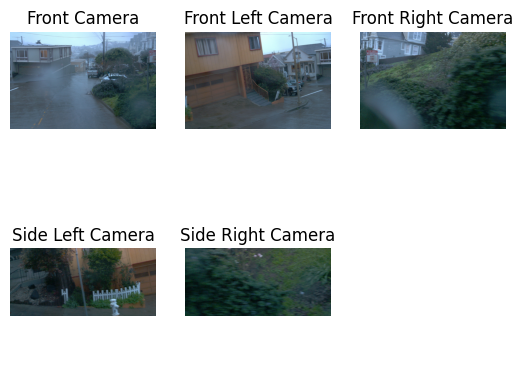

In [6]:
from PIL import Image
import io
import matplotlib.pyplot as plt

front_image_raw = cam_df[cam_df["key.camera_name"] == 1].iloc[0]["[CameraImageComponent].image"] # 1=FRONT, 2=FRONT_LEFT, 3=FRONT_RIGHT, 4=SIDE_LEFT, 5=SIDE_RIGHT
front_im = Image.open(io.BytesIO(front_image_raw))
front_left_image_raw = cam_df[cam_df["key.camera_name"] == 2].iloc[0]["[CameraImageComponent].image"]
front_left_im = Image.open(io.BytesIO(front_left_image_raw))
front_right_image_raw = cam_df[cam_df["key.camera_name"] == 3].iloc[0]["[CameraImageComponent].image"]
front_right_im = Image.open(io.BytesIO(front_right_image_raw))
side_left_image_raw = cam_df[cam_df["key.camera_name"] == 4].iloc[0]["[CameraImageComponent].image"]
side_left_im = Image.open(io.BytesIO(side_left_image_raw))
side_right_image_raw = cam_df[cam_df["key.camera_name"] == 5].iloc[0]["[CameraImageComponent].image"]
side_right_im = Image.open(io.BytesIO(side_right_image_raw))
#plot all images in a 2x3 grid
fig, axs = plt.subplots(2, 3)
axs[0, 0].imshow(front_im)
axs[0, 0].axis('off')
axs[0, 0].set_title("Front Camera")
axs[0, 1].imshow(front_left_im)
axs[0, 1].axis('off')
axs[0, 1].set_title("Front Left Camera")
axs[0, 2].imshow(front_right_im)
axs[0, 2].axis('off')
axs[0, 2].set_title("Front Right Camera")
axs[1, 0].imshow(side_left_im)
axs[1, 0].axis('off')
axs[1, 0].set_title("Side Left Camera")
axs[1, 1].imshow(side_right_im)
axs[1, 1].axis('off')
axs[1, 1].set_title("Side Right Camera")
plt.axis('off')
plt.show()

# Load camera GT box

In [13]:
cam_label_parquet_path = "/workspaces/object_detection/data/waymo/raw/training/camera_box/10017090168044687777_6380_000_6400_000.parquet"
cam_labels_df = pq.read_table(cam_label_parquet_path).to_pandas()
cam_df_with_labels = pd.merge(cam_df, cam_labels_df, on=["key.segment_context_name", "key.frame_timestamp_micros", "key.camera_name"], how="left")
print(cam_df_with_labels.columns)
cam_df_with_labels.iloc[0][[ "[CameraBoxComponent].type"]]

Index(['key.segment_context_name', 'key.frame_timestamp_micros',
       'key.camera_name', '[CameraImageComponent].image',
       'key.camera_object_id', '[CameraBoxComponent].box.center.x',
       '[CameraBoxComponent].box.center.y', '[CameraBoxComponent].box.size.x',
       '[CameraBoxComponent].box.size.y', '[CameraBoxComponent].type',
       '[CameraBoxComponent].difficulty_level.detection',
       '[CameraBoxComponent].difficulty_level.tracking'],
      dtype='object')


[CameraBoxComponent].type    1.0
Name: 0, dtype: object

# Project label into image

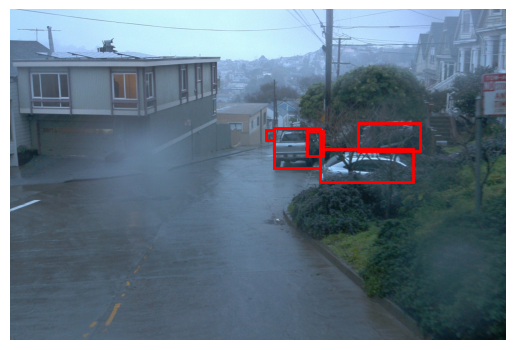

In [8]:
front_image = cam_df_with_labels[cam_df_with_labels["key.camera_name"] == 1].iloc[0]["[CameraImageComponent].image"]
front_im = Image.open(io.BytesIO(front_image))
# Get the corresponding labels for the front camera frame
frame = cam_df[cam_df["key.camera_name"] == 1].iloc[0]
segment  = frame["key.segment_context_name"]
timestamp = frame["key.frame_timestamp_micros"]
frame_boxes = cam_df_with_labels[
    (cam_df_with_labels["key.segment_context_name"] == segment) &
    (cam_df_with_labels["key.frame_timestamp_micros"] == timestamp) &
    (cam_df_with_labels["key.camera_name"] == 1)
]
fig, ax = plt.subplots()
ax.imshow(front_im)
ax.axis('off')
for _, box in frame_boxes.iterrows():
    x_center = box["[CameraBoxComponent].box.center.x"]
    y_center = box["[CameraBoxComponent].box.center.y"]
    width    = box["[CameraBoxComponent].box.size.x"]
    height   = box["[CameraBoxComponent].box.size.y"]
    obj_type = box["[CameraBoxComponent].type"]

    x1 = x_center - width / 2
    y1 = y_center - height / 2

    color = {1: 'red', 2: 'cyan', 3: 'yellow', 4: 'lime'}.get(obj_type, 'white')
    ax.add_patch(plt.Rectangle((x1, y1), width, height,
                                edgecolor=color, facecolor='none', linewidth=2))
plt.show()

# Load and plot lidar range image

In [9]:
import pyarrow.parquet as pq
import numpy as np
lidar_parquet_file = "/workspaces/object_detection/data/waymo/raw/training/lidar/10017090168044687777_6380_000_6400_000.parquet"
schema = pq.read_schema(lidar_parquet_file)
print(schema)
#lidar_df = pq.read_table(lidar_parquet_file).to_pandas()
#row = lidar_df[lidar_df['key.laser_name'] == 1].iloc[0]  # 1 = TOP lidar


index: string
key.segment_context_name: string
key.frame_timestamp_micros: int64
key.laser_name: int8
[LiDARComponent].range_image_return1.values: list<item: float>
  child 0, item: float
[LiDARComponent].range_image_return1.shape: fixed_size_list<item: int32>[3]
  child 0, item: int32
[LiDARComponent].range_image_return2.values: list<item: float>
  child 0, item: float
[LiDARComponent].range_image_return2.shape: fixed_size_list<item: int32>[3]
  child 0, item: int32
-- schema metadata --
pandas: '{"column_indexes": [{"field_name": null, "metadata": {"encoding"' + 1459


In [10]:
# 2. Load only TOP lidar rows, and only the columns you actually need
table = pq.read_table(
    lidar_parquet_file,
    filters=[('key.laser_name', '=', 1)],   # pushdown filter — only TOP lidar - avoids OOM
    columns=[
        'key.segment_context_name',
        'key.frame_timestamp_micros',
        'key.laser_name',
        '[LiDARComponent].range_image_return1.values',
        '[LiDARComponent].range_image_return1.shape',
    ]
)
df = table.to_pandas()
row = df.iloc[0]

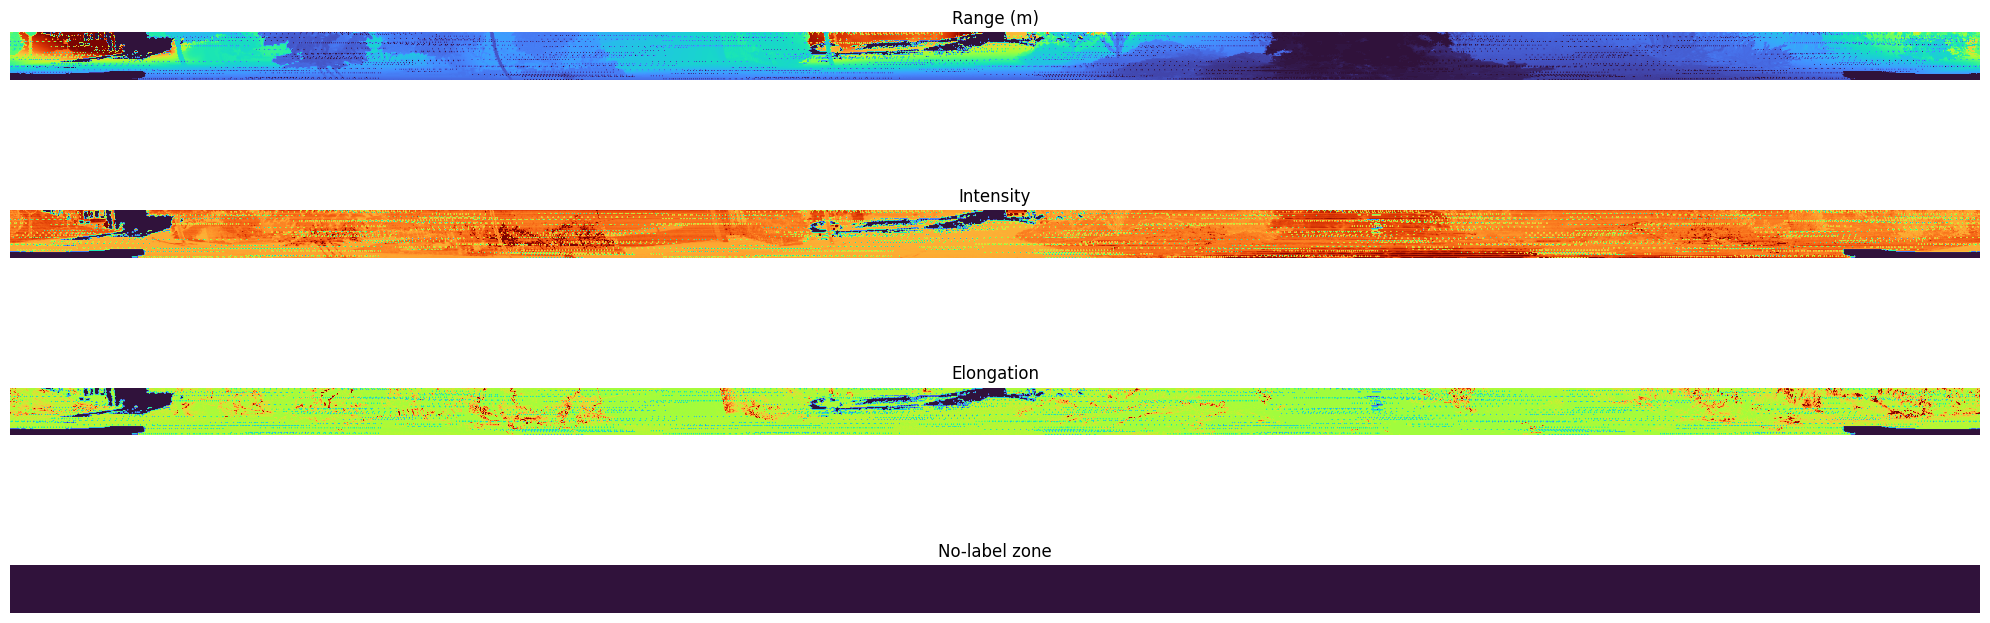

In [6]:
import matplotlib.pyplot as plt
import numpy as np

ri_values = np.array(row['[LiDARComponent].range_image_return1.values'])
ri_shape  = row['[LiDARComponent].range_image_return1.shape']
H, W      = ri_shape[0], ri_shape[1]
ri        = ri_values.reshape(H, W, 4)

# Plot all 4 channels
fig, axes = plt.subplots(4, 1, figsize=(20, 8))
titles = ['Range (m)', 'Intensity', 'Elongation', 'No-label zone']

for i, (ax, title) in enumerate(zip(axes, titles)):
    channel = ri[:, :, i]
    valid = channel > 0 if i == 0 else np.ones_like(channel, dtype=bool)
    ax.imshow(channel, cmap='turbo', vmin=np.percentile(channel[valid], 1),
                                     vmax=np.percentile(channel[valid], 99))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Load lidar boxes

In [11]:
lidar_label_parquet_path = "/workspaces/object_detection/data/waymo/raw/training/lidar_box/10017090168044687777_6380_000_6400_000.parquet"
lidar_labels_df = pq.read_table(lidar_label_parquet_path).to_pandas()
print(lidar_labels_df.columns)

Index(['key.segment_context_name', 'key.frame_timestamp_micros',
       'key.laser_object_id', '[LiDARBoxComponent].box.center.x',
       '[LiDARBoxComponent].box.center.y', '[LiDARBoxComponent].box.center.z',
       '[LiDARBoxComponent].box.size.x', '[LiDARBoxComponent].box.size.y',
       '[LiDARBoxComponent].box.size.z', '[LiDARBoxComponent].box.heading',
       '[LiDARBoxComponent].type',
       '[LiDARBoxComponent].num_lidar_points_in_box',
       '[LiDARBoxComponent].num_top_lidar_points_in_box',
       '[LiDARBoxComponent].speed.x', '[LiDARBoxComponent].speed.y',
       '[LiDARBoxComponent].speed.z', '[LiDARBoxComponent].acceleration.x',
       '[LiDARBoxComponent].acceleration.y',
       '[LiDARBoxComponent].acceleration.z',
       '[LiDARBoxComponent].difficulty_level.detection',
       '[LiDARBoxComponent].difficulty_level.tracking'],
      dtype='object')
